In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\ExcelData\Customer Churn.csv")

In [11]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [17]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Cleaning:** Replaced blank values in the `TotalCharges` column with **0**, as these records correspond to customers with **zero tenure** who have not yet accumulated any charges.

In [25]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df.isnull().sum().sum()

np.int64(0)

In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [38]:
df['customerID'].duplicated().sum()

np.int64(0)

In [39]:
df.duplicated().sum()

np.int64(0)

**Data Cleaning:** Replaced the numeric values (**0** and **1**) in the `SeniorCitizen` column with descriptive labels (**No** and **Yes**) for better understanding.

In [41]:
def con(value):
    if value == 1:
        return "yes"
    else:
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(con)

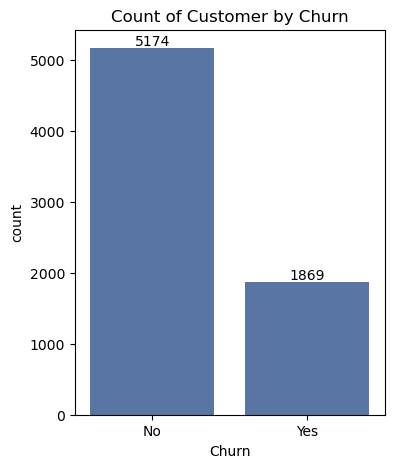

In [184]:
plt.figure(figsize = (4,5))

ax = sns.countplot(x = df['Churn'],
                   color='#4C72B0')

ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn")
plt.show()

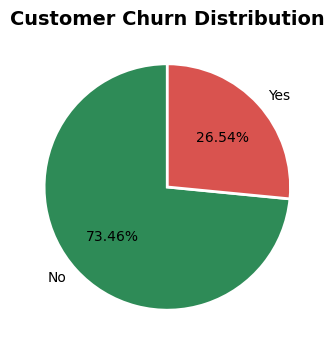

In [180]:
gb = df.groupby('Churn').agg({'Churn':'count'})

colors = ['#2E8B57', '#D9534F']

plt.figure(figsize=(4,4))

plt.pie(
    gb['Churn'],
    labels=gb.index,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.show()

**Observation:** The pie chart indicates that **26.54% of customers have churned**, while **73.46% have been retained**. The following analysis explores the key factors contributing to customer churn.

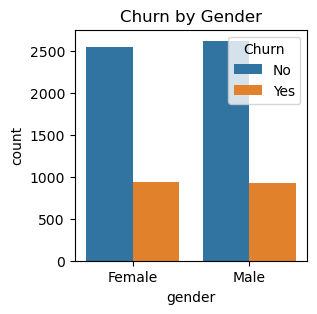

In [183]:
plt.figure(figsize = (3,3))

sns.countplot(x = 'gender',
              data = df,
              hue = 'Churn')

plt.title("Churn by Gender")
plt.show()

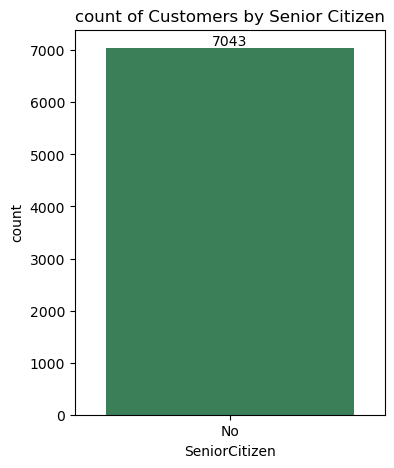

In [195]:
plt.figure(figsize = (4,5))

ax = sns.countplot(x = 'SeniorCitizen',
                   data = df,
                  color = '#2E8B57')

ax.bar_label(ax.containers[0])
plt.title("count of Customers by Senior Citizen")
plt.show()

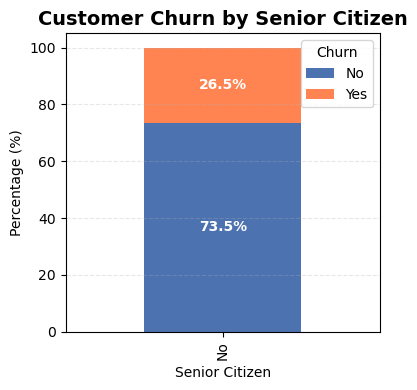

In [190]:
gb = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

ax = gb.plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    color=['#4C72B0', '#ff8452'] 
    
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',
                 color='white', fontsize=10, fontweight='bold')


plt.title("Customer Churn by Senior Citizen", fontsize=14, fontweight='bold')
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** Senior citizens exhibit a higher churn rate compared to non-senior customers, indicating they are more likely to discontinue the service.

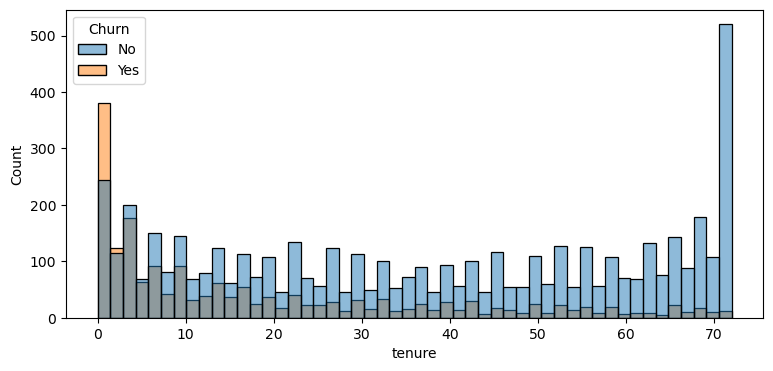

In [181]:
plt.figure(figsize=(9,4))

sns.histplot(x = 'tenure',
             data = df,
             color='#5B7DB1',
             bins=50,
             hue = 'Churn')
plt.show()

**Observation:** Customers with a longer tenure are more likely to remain with the company, whereas customers with a tenure of only 1–2 months exhibit the highest churn rate.

C:\Users\ayush\AppData\Local\Temp\ipykernel_23868\133406680.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#6C757D'` for the same effect.

  ax = sns.countplot(x = 'Contract',


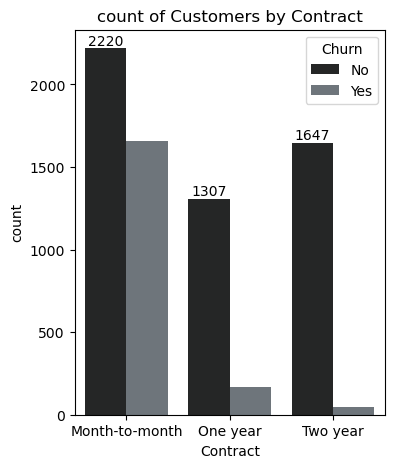

In [200]:
plt.figure(figsize = (4,5))

ax = sns.countplot(x = 'Contract',
                   data = df,
                   color = '#6C757D',
                   hue = 'Churn')

ax.bar_label(ax.containers[0])
plt.title("count of Customers by Contract")
plt.show()

**Observation:** Customers with **month-to-month contracts** exhibit a significantly higher churn rate compared to customers with **one-year** and **two-year contracts**.

In [206]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

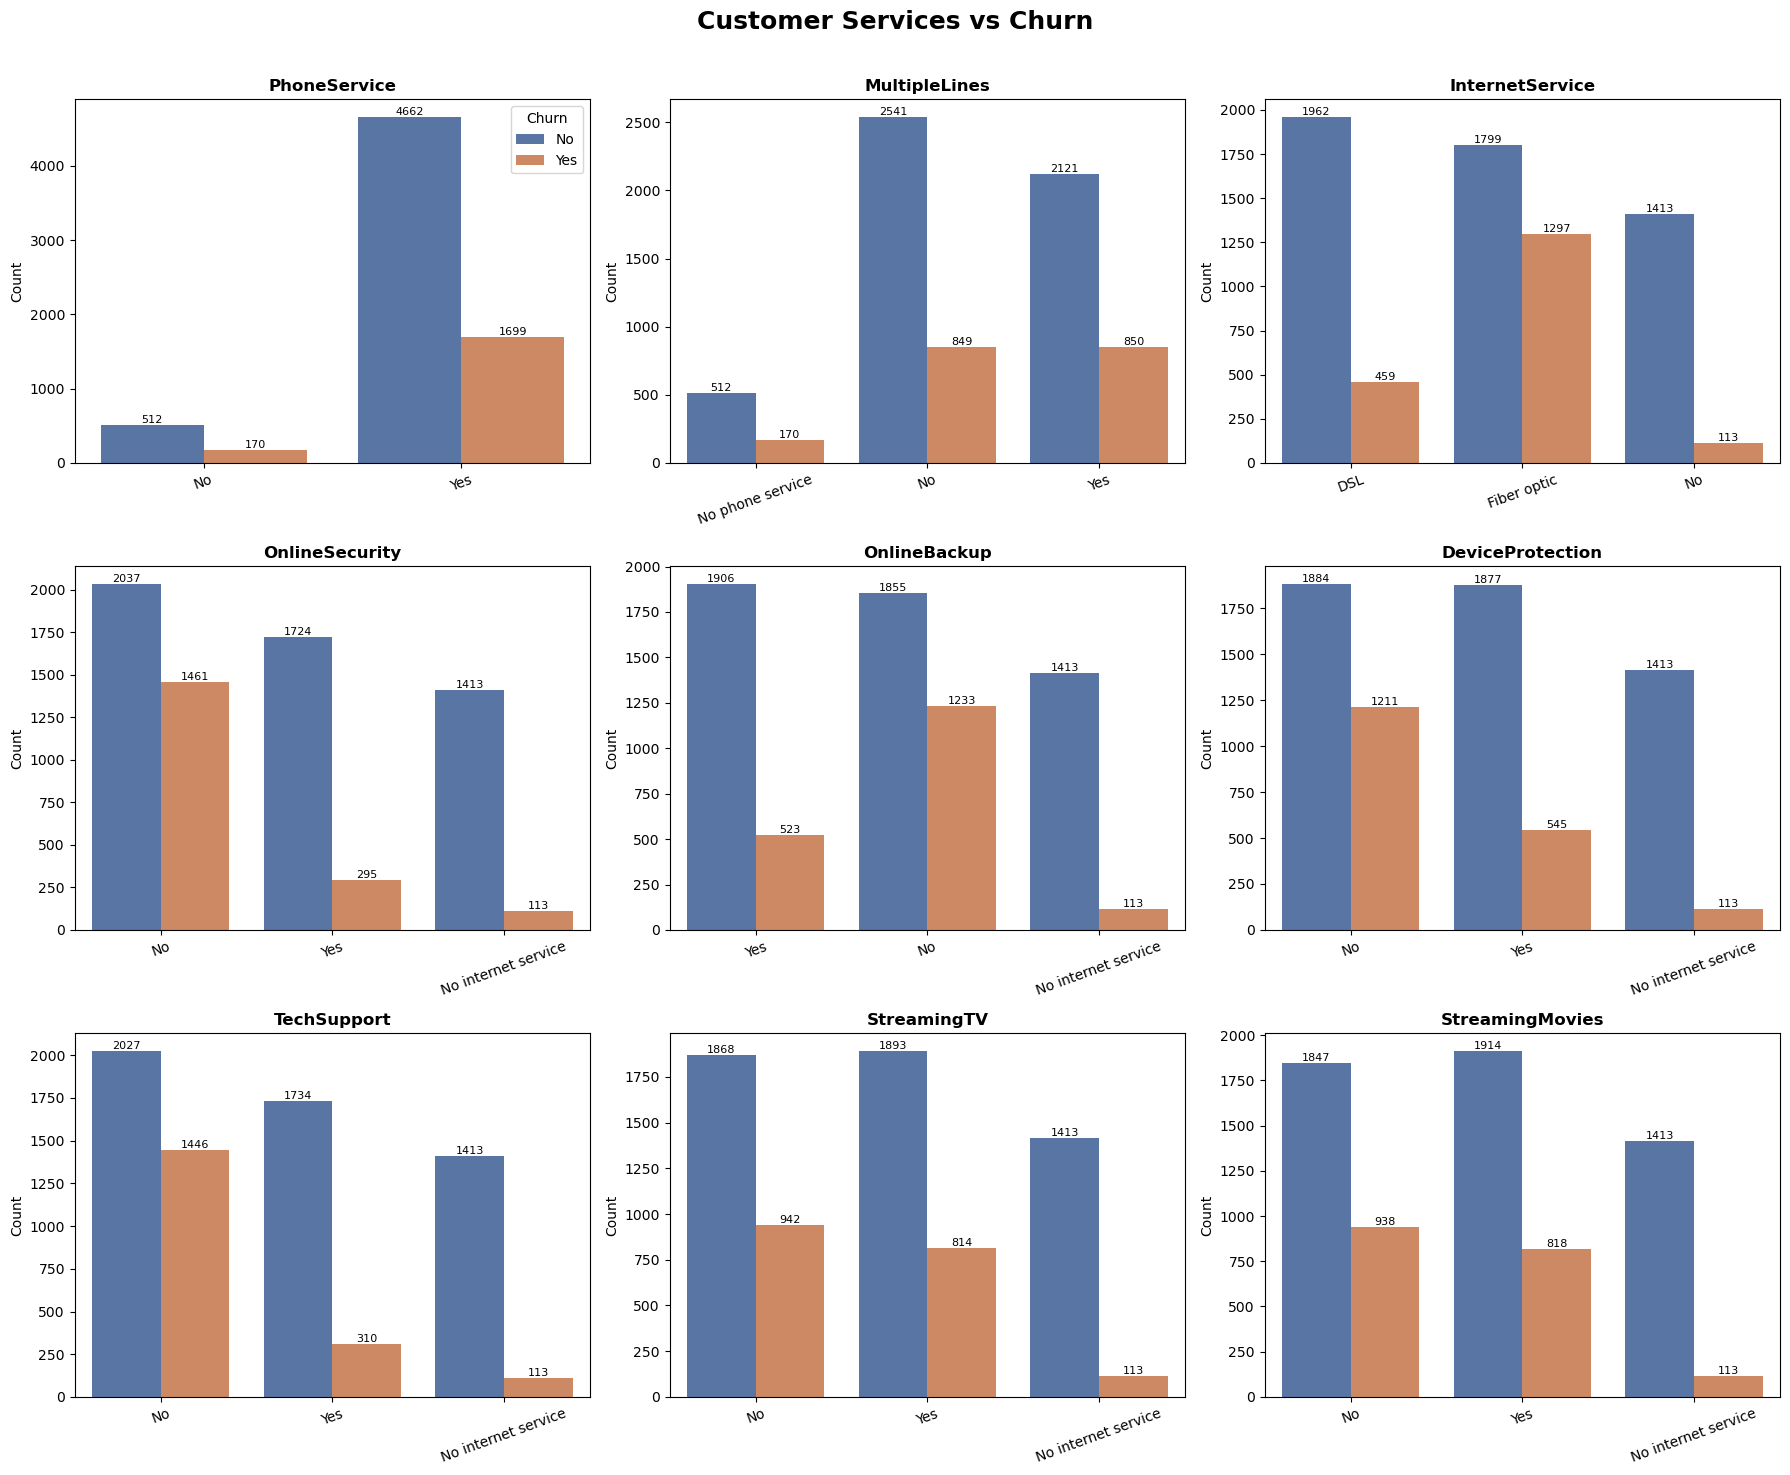

In [211]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

palette = {
    'No': '#4C72B0',     
    'Yes': '#DD8452'    
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        palette=palette,
        ax=axes[i]
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=20)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Churn")

for ax in axes[1:]:
    if ax.get_legend():
        ax.get_legend().remove()

plt.suptitle("Customer Services vs Churn", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Key Insights

- Customers **without Online Security, Tech Support, Online Backup, and Device Protection** are more likely to churn.
- Customers using **Fiber Optic Internet** exhibit the highest churn rate among internet service types.
- **Phone Service** and **Multiple Lines** have a relatively small impact on customer churn.
- **Streaming TV** and **Streaming Movies** show no significant effect on customer retention.

**Overall:** Value-added support and security services improve customer retention, while Fiber Optic customers represent the highest-risk segment for churn.

C:\Users\ayush\AppData\Local\Temp\ipykernel_23868\3680898710.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#DD8452'` for the same effect.

  ax = sns.countplot(x = 'PaymentMethod',


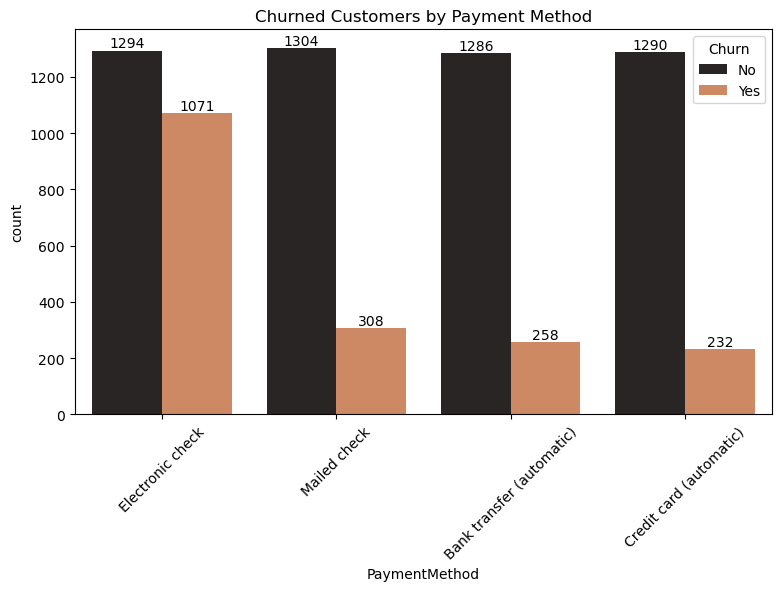

In [221]:
plt.figure(figsize = (9,5))

ax = sns.countplot(x = 'PaymentMethod',
                   data = df,
                   color = '#DD8452',
                   hue = 'Churn')

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

**Observation:** Customers who use **Electronic Check** as their payment method exhibit the highest churn rate compared to customers using other payment methods.